# FINM 33100 - Track 1: Market Structure


## 1. Load and validate the stock-level data

The dataset is loaded from the project data directory. We use `permno` as the permanent security identifier, `date` as the trading date, `ret` as the daily return, and `mcap` as market capitalization.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "olhcv_merged.parquet"
CCM_LINKTABLE_PATH = PROJECT_ROOT / "data" / "ccm_linktable.csv"

for required_path in (DATA_PATH, CCM_LINKTABLE_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Data file not found: {required_path}")

def format_market_data_for_display(data_frame):
    display_frame = data_frame.copy()
    if "ret" in display_frame.columns:
        display_frame["ret"] = display_frame["ret"] * 100
    if "mcap" in display_frame.columns:
        display_frame["mcap"] = display_frame["mcap"] / 1_000_000
    return display_frame.rename(columns={"ret": "ret (%)", "mcap": "mcap ($ millions)"})

stock_panel = pd.read_parquet(DATA_PATH)
stock_panel["date"] = pd.to_datetime(stock_panel["date"], errors="coerce")
stock_panel["permno"] = pd.to_numeric(stock_panel["permno"], errors="coerce").astype("Int64")
stock_panel = stock_panel.sort_values(["permno", "date"]).reset_index(drop=True)
stock_panel["stock_name"] = stock_panel["ticker"].astype("string")

# Match each CRSP security to the CCM company name in force on its observation date.
ccm_links = pd.read_csv(CCM_LINKTABLE_PATH, dtype={"LPERMNO": "Int64"})
ccm_links["link_start"] = pd.to_datetime(ccm_links["LINKDT"], errors="coerce")
ccm_links["link_end"] = pd.to_datetime(ccm_links["LINKENDDT"], errors="coerce")
ccm_links["link_end"] = ccm_links["link_end"].fillna(pd.Timestamp.max)
ccm_links = ccm_links.loc[
    ccm_links["LPERMNO"].notna()
    & ccm_links["conm"].notna()
    & ccm_links["link_start"].notna()
    & ccm_links["LINKPRIM"].isin(["P", "C"])
].copy()
ccm_links = ccm_links.rename(columns={"LPERMNO": "permno", "conm": "company_name"})

# merge_asof requires the merge key to be globally sorted. Sort by date first,
# then use permno as the within-date grouping key.
stock_panel_for_merge = stock_panel.sort_values(["date", "permno"]).reset_index(drop=True)
ccm_links_for_merge = ccm_links.sort_values(["link_start", "permno"]).reset_index(drop=True)

stock_panel = pd.merge_asof(
    stock_panel_for_merge,
    ccm_links_for_merge[["permno", "link_start", "link_end", "company_name"]],
    left_on="date",
    right_on="link_start",
    by="permno",
    direction="backward",
    allow_exact_matches=True,
)
stock_panel["company_name"] = stock_panel["company_name"].astype("string").where(
    stock_panel["date"].le(stock_panel["link_end"])
)
stock_panel = stock_panel.drop(columns=["link_start", "link_end"])
stock_panel = stock_panel.sort_values(["date", "permno"]).reset_index(drop=True)

required_columns = {"date", "permno", "ret", "mcap"}
missing_required_columns = required_columns.difference(stock_panel.columns)
if missing_required_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_required_columns)}")

invalid_dates = stock_panel["date"].isna().sum()
duplicate_security_dates = stock_panel.duplicated(["permno", "date"]).sum()
if duplicate_security_dates:
    stock_panel = stock_panel.drop_duplicates(["permno", "date"], keep="last").copy()

stock_panel["year"] = stock_panel["date"].dt.year
stock_panel["month"] = stock_panel["date"].dt.to_period("M")
stock_panel["eligible_mcap"] = stock_panel["mcap"].where(stock_panel["mcap"] > 0)
stock_panel["valid_return"] = stock_panel["ret"].notna()

print(f"Rows loaded:                {len(stock_panel):>12,}")
print(f"Columns loaded:             {stock_panel.shape[1]:>12,}")
print(f"Date range:                 {stock_panel['date'].min().date()} to {stock_panel['date'].max().date()}")
print(f"Unique securities:          {stock_panel['permno'].nunique():>12,}")
print(f"Company names matched:      {stock_panel['company_name'].notna().sum():>12,}")
print(f"Invalid dates:              {invalid_dates:>12,}")
print(f"Duplicate permno-dates:     {duplicate_security_dates:>12,}")

print("Missing values in core fields:")
display(stock_panel[["date", "permno", "ret", "mcap", "company_name"]].isna().sum().to_frame("missing_count"))
print("Sanity-check rows (returns in percent and market capitalization in millions of dollars):")
display(format_market_data_for_display(stock_panel[["date", "permno", "ticker", "company_name", "ret", "mcap"]].head(3)))

Rows loaded:                   6,255,075
Columns loaded:                       20
Date range:                 2001-02-01 to 2025-12-31
Unique securities:                 3,256
Company names matched:         6,229,568
Invalid dates:                         0
Duplicate permno-dates:                0
Missing values in core fields:


,missing_count
date,0
permno,0
ret,112
mcap,1180
company_name,25507


Sanity-check rows (returns in percent and market capitalization in millions of dollars):


,date,permno,ticker,company_name,ret (%),mcap ($ millions)
0,2001-02-01,10032,PLXS,PLEXUS CORP,4.926800,"2,022.549750"
1,2001-02-01,10078,SUNW,SUN MICROSYSTEMS INC,1.840500,"101,463.391500"
2,2001-02-01,10104,ORCL,ORACLE CORP,3.218900,"167,926.659875"


## Daily Summary and Diagnostics of the Data - Validation

Before constructing the point-in-time market index, we summarize the stock universe and return data. These diagnostics report the number of observed securities and observations, missing-return rates, positive market-cap counts, security histories, and the distribution of daily returns.

In [2]:
daily_universe_summary = (
    stock_panel.groupby("date")["permno"]
    .nunique()
    .rename("securities_observed")
    .to_frame()
)

print(f"Date range: {daily_universe_summary.index.min().date()} to {daily_universe_summary.index.max().date()}")
print(f"Median daily securities: {daily_universe_summary['securities_observed'].median():,.0f}")

Date range: 2001-02-01 to 2025-12-31
Median daily securities: 999


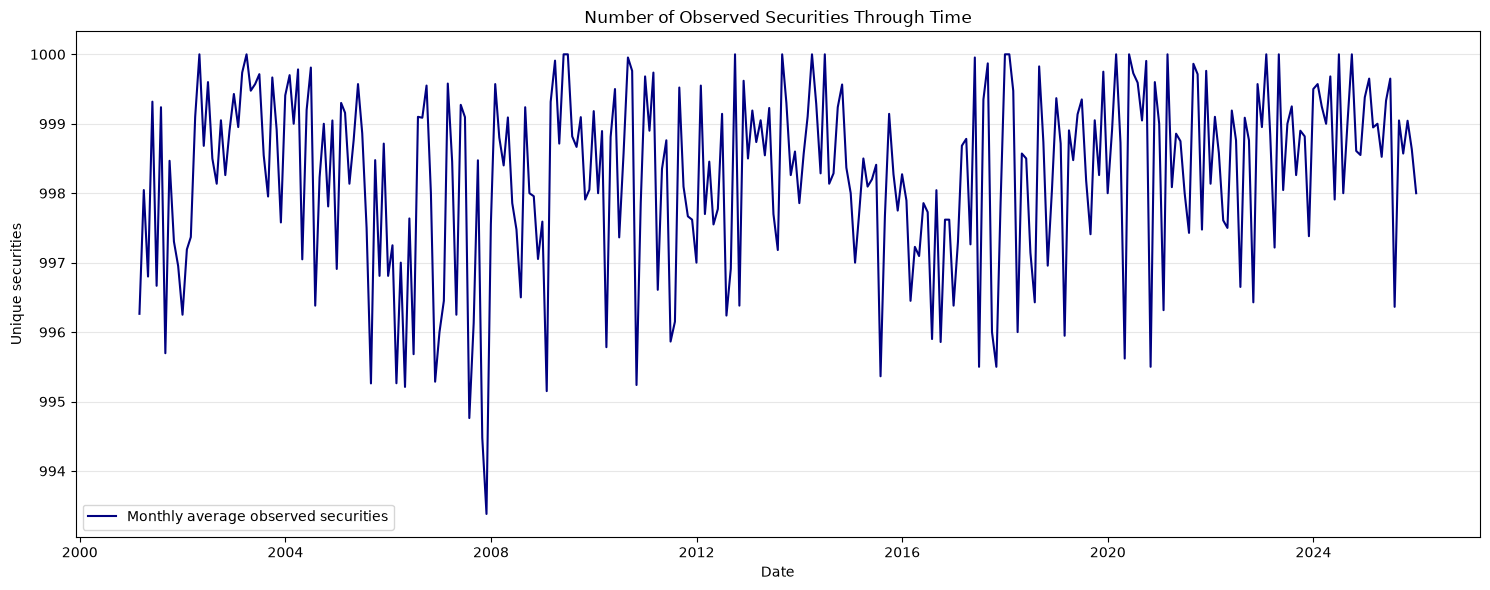

In [3]:
monthly_observed_securities = daily_universe_summary["securities_observed"].resample("ME").mean()

fig, axis = plt.subplots(figsize=(15, 6))
axis.plot(
    monthly_observed_securities.index,
    monthly_observed_securities,
    color="navy",
    linewidth=1.5,
    label="Monthly average observed securities",
)
axis.set(
    title="Number of Observed Securities Through Time",
    xlabel="Date",
    ylabel="Unique securities",
)
axis.grid(axis="y", alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

## 2. Point-in-time top-1,000 market index

Creating a market index to see how the broad market (top 1000 stocks) does overall before going deeper into intra stock correlations.

In [4]:
index_panel = stock_panel.copy()

index_panel["lagged_mcap"] = index_panel.groupby("permno")["mcap"].shift(1)
index_panel["return_for_index"] = index_panel["ret"]

month_end_market_cap = index_panel.loc[index_panel["eligible_mcap"].notna(), ["permno", "month", "mcap", "stock_name"]].sort_values(["month", "permno"]).groupby(["month", "permno"], as_index=False).last()
month_end_market_cap["holding_month"] = month_end_market_cap["month"] + 1
month_end_market_cap = month_end_market_cap.sort_values(["holding_month", "mcap"], ascending=[True, False])
# Rank the largest market-cap securities each month.
month_end_market_cap["market_cap_rank"] = month_end_market_cap.groupby("holding_month").cumcount() + 1
ranked_membership = month_end_market_cap.loc[month_end_market_cap["market_cap_rank"] <= 1_000].copy()

index_panel = index_panel.merge(ranked_membership[["holding_month", "permno", "market_cap_rank"]], left_on=["month", "permno"], right_on=["holding_month", "permno"], how="left", validate="many_to_one")
index_panel["index_eligible"] = (
    index_panel["market_cap_rank"].notna()
    & (index_panel["lagged_mcap"] > 0)
    & index_panel["return_for_index"].notna()
)
index_eligible_panel = index_panel.loc[index_panel["index_eligible"]].copy()

def aggregate_index_returns(day_rows):
    return pd.Series({
        "equal_weighted_return": day_rows["return_for_index"].mean(),
        "cap_weighted_return": np.average(
            day_rows["return_for_index"], weights=day_rows["lagged_mcap"]
        ),
        "securities_used": len(day_rows),
    })

market_index_daily = index_eligible_panel.groupby("date", sort=True).apply(aggregate_index_returns, include_groups=False)
market_index_daily.index = pd.to_datetime(market_index_daily.index)
market_index_daily["equal_weight_cumulative"] = (1 + market_index_daily["equal_weighted_return"]).cumprod()
market_index_daily["cap_weight_cumulative"] = (1 + market_index_daily["cap_weighted_return"]).cumprod()
print(f"Rebalance months: {ranked_membership['holding_month'].nunique():,}")
print(f"Median securities used per day: {market_index_daily['securities_used'].median():,.0f}")
print("Top-1,000 membership with returns in percent and market capitalization in millions of dollars:")
display(format_market_data_for_display(ranked_membership[["holding_month", "permno", "stock_name", "mcap", "market_cap_rank"]].head()))

Rebalance months: 299
Median securities used per day: 974
Top-1,000 membership with returns in percent and market capitalization in millions of dollars:


,holding_month,permno,stock_name,mcap ($ millions),market_cap_rank
63,2001-03,12060,GE,"460,759.293000",1
3,2001-03,10107,MSFT,"314,788.069000",2
156,2001-03,21936,PFE,"283,906.755000",3
53,2001-03,11850,XOM,"281,745.118450",4
515,2001-03,70519,C,"250,262.659440",5


## 3. A wholistic view of what the market looks like over time

This is the first section where real analysis begins

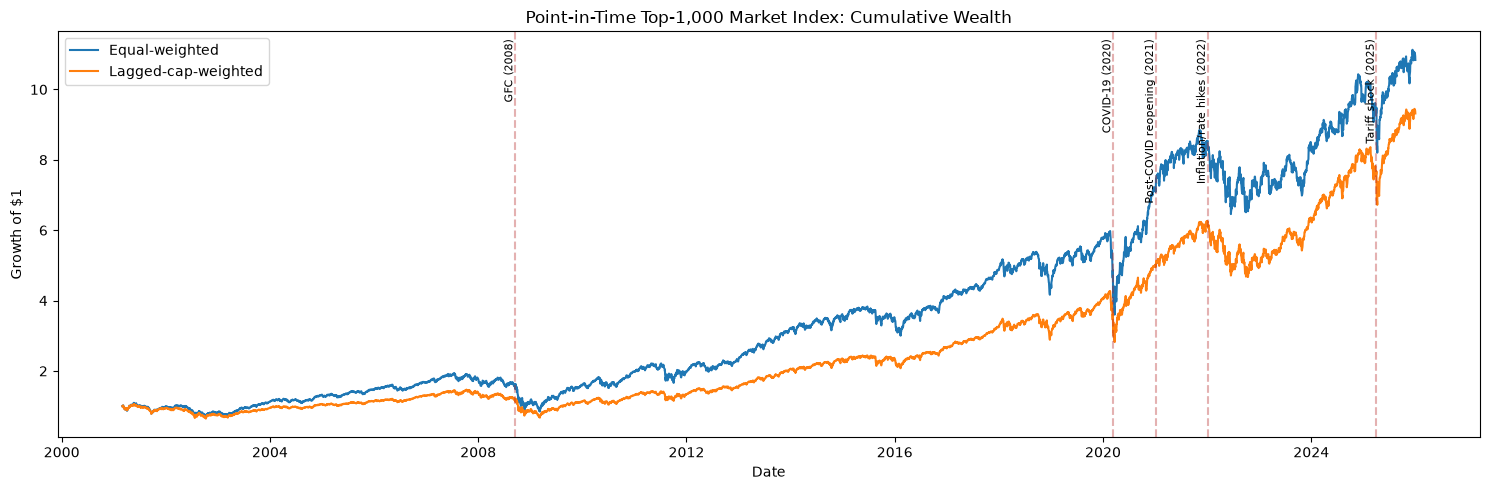

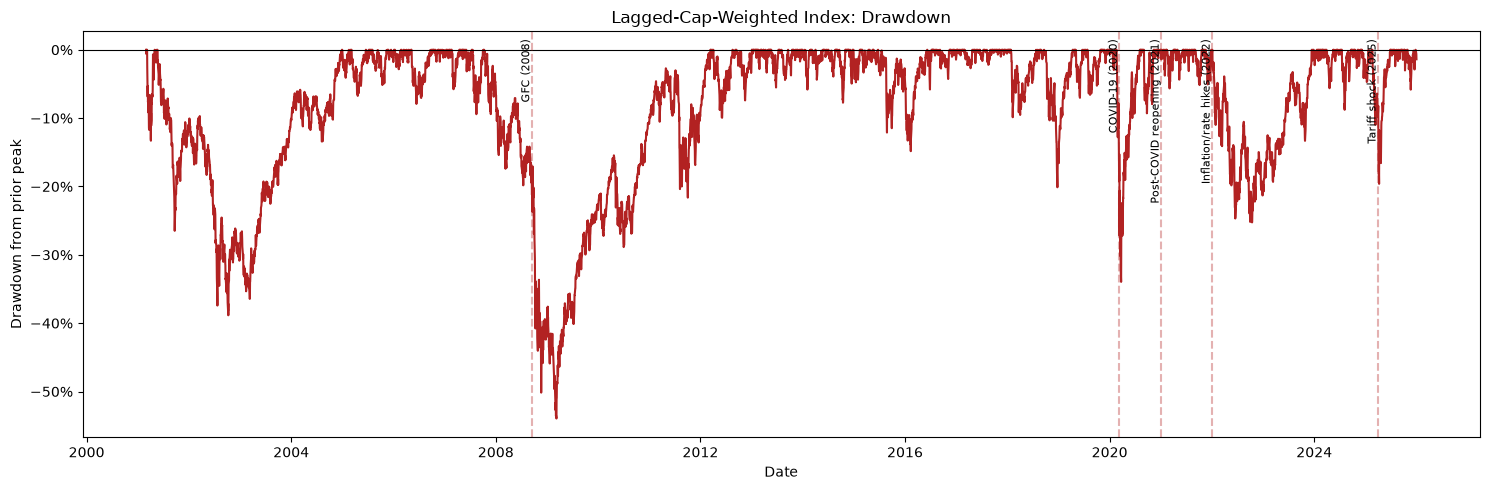

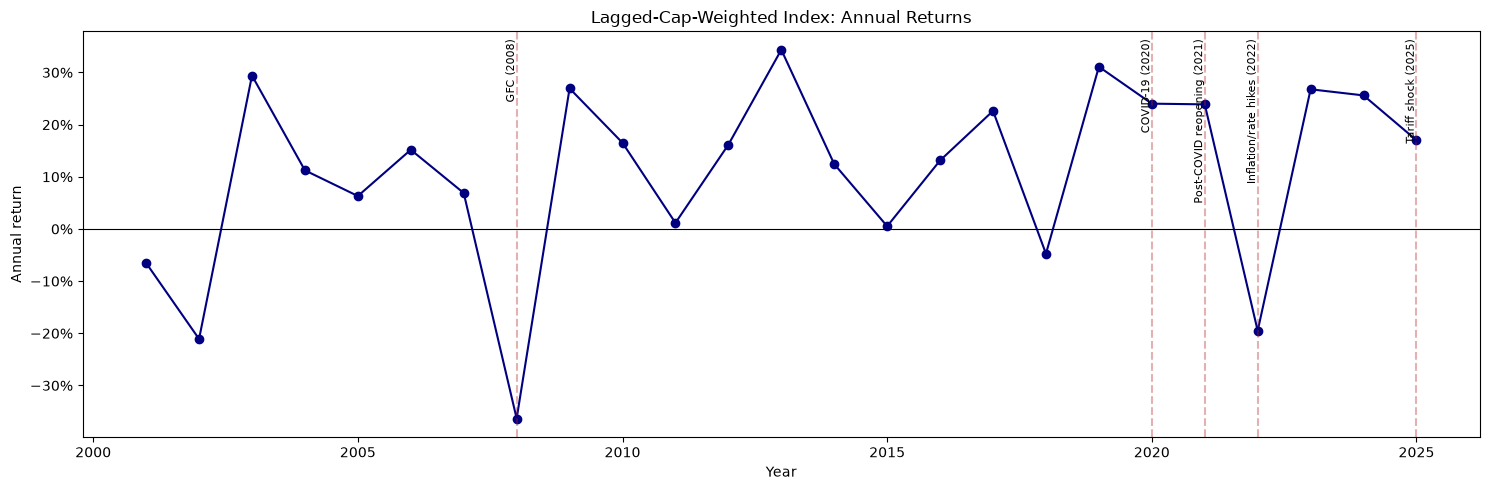

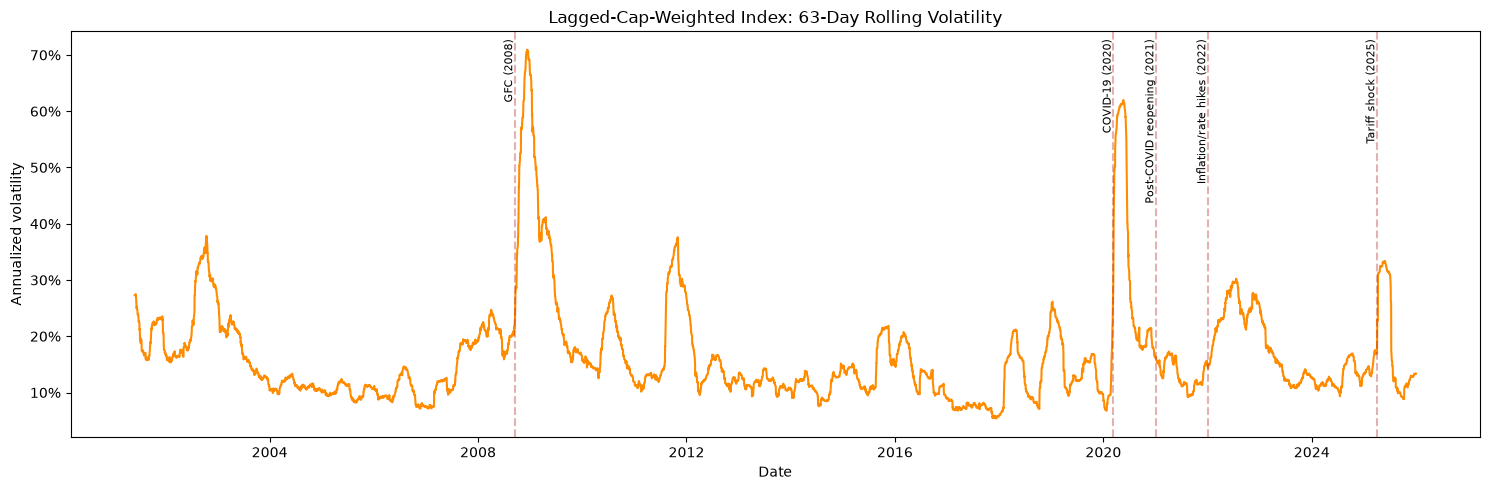

In [5]:
from matplotlib.ticker import PercentFormatter

# Keep the overview focused on the lagged-cap-weighted index; compare weighting schemes only in wealth.
cap_weighted_returns = market_index_daily["cap_weighted_return"]
annual_performance = cap_weighted_returns.groupby(cap_weighted_returns.index.year).agg(
    annual_return=lambda values: (1 + values).prod() - 1,
    annualized_volatility=lambda values: values.std() * np.sqrt(252),
)

cap_weighted_wealth = (1 + cap_weighted_returns).cumprod()
cap_weighted_drawdown = cap_weighted_wealth / cap_weighted_wealth.cummax() - 1
annual_performance["maximum_drawdown"] = cap_weighted_drawdown.groupby(cap_weighted_drawdown.index.year).min()

rolling_volatility = cap_weighted_returns.rolling(63).std() * np.sqrt(252)
stress_periods = {
    "GFC": pd.Timestamp("2008-09-15"),
    "COVID-19": pd.Timestamp("2020-03-11"),
    "Post-COVID reopening": pd.Timestamp("2021-01-04"),
    "Inflation/rate hikes": pd.Timestamp("2022-01-03"),
    "Tariff shock": pd.Timestamp("2025-04-02"),
}

def add_stress_markers(axis, annual=False):
    for label, stress_date in stress_periods.items():
        marker = stress_date.year if annual else stress_date
        axis.axvline(marker, color="firebrick", linestyle="--", alpha=0.35)
        axis.text(marker, 0.98, f"{label} ({stress_date.year})", transform=axis.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8)

# 1. Compare the two weighting schemes only in cumulative wealth.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(market_index_daily.index, market_index_daily["equal_weight_cumulative"], label="Equal-weighted")
axis.plot(market_index_daily.index, market_index_daily["cap_weight_cumulative"], label="Lagged-cap-weighted")
add_stress_markers(axis)
axis.set(title="Point-in-Time Top-1,000 Market Index: Cumulative Wealth", xlabel="Date", ylabel="Growth of $1")
axis.legend()
figure.tight_layout()
plt.show()

# 2. Drawdown of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(cap_weighted_drawdown, color="firebrick")
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Lagged-Cap-Weighted Index: Drawdown", xlabel="Date", ylabel="Drawdown from prior peak")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis)
figure.tight_layout()
plt.show()

# 3. Calendar-year returns of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(annual_performance.index, annual_performance["annual_return"], marker="o", color="navy")
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Lagged-Cap-Weighted Index: Annual Returns", xlabel="Year", ylabel="Annual return")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis, annual=True)
axis.yaxis.set_major_formatter(PercentFormatter(1))
figure.tight_layout()
plt.show()

# 4. Changing short-horizon risk of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(rolling_volatility, color="darkorange")
axis.set(title="Lagged-Cap-Weighted Index: 63-Day Rolling Volatility", xlabel="Date", ylabel="Annualized volatility")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis)
figure.tight_layout()
plt.show()

## Summarising Broad Market ##
- Equal weighted index has a higher return than the market-cap weighted index. This is because the equal weighted index gives more weight to smaller stocks which have higher returns on average. This is an expected result.
- In terms of drawdown, GFC has been the worst in this period followed by covid. The period in 2022-2023 looks interesting as well. That is a period that might be worth exploring as well in terms of market stress scenario.
- Continuing the trend of drawdown, volatility shows similar pattern for spikes. Again, GFC and covid would be the periods of interest to study deeper to analyse diversification benefits and correlation structure of the market.

## 5. Rolling average pairwise correlation

For each sampled date, a correlation matrix is computed over the trailing 252-day window across the index-eligible universe, then reduced to the average pairwise correlation. Stress periods are highlighted to show how market-wide synchronization changes during crises.

Rolling window: 252 trading days, sampled every 21 days
Maximum top-market-cap securities per window: 250
Evaluation dates: 286
Average pairwise correlation range: 0.135 to 0.567


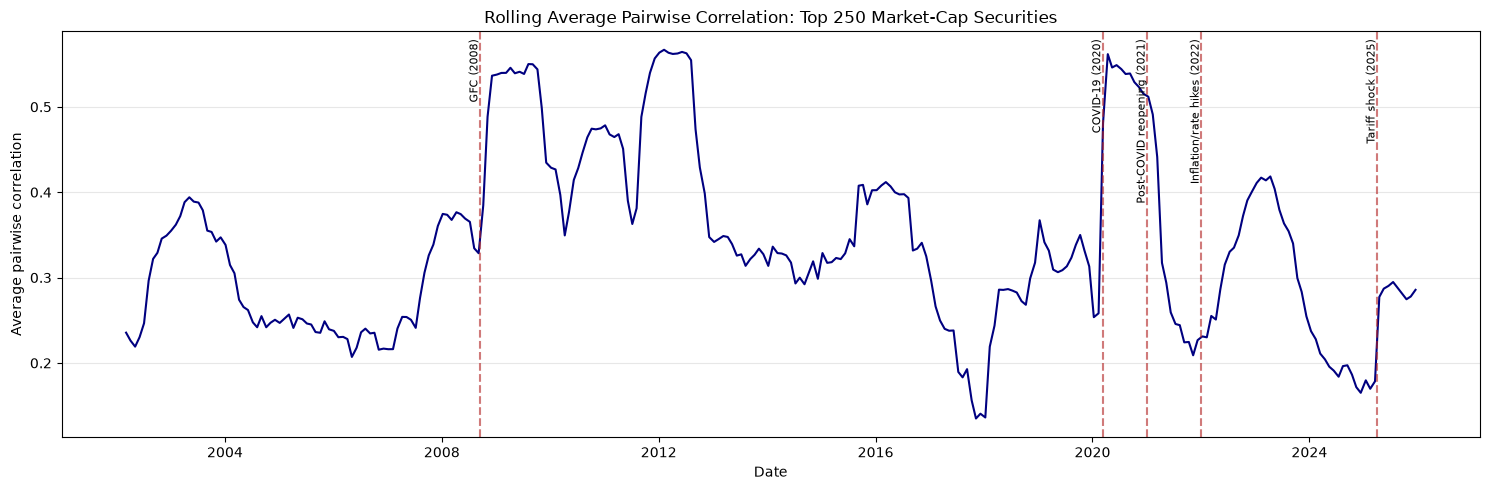

In [6]:
# Cap the rolling correlation matrix at the largest securities by lagged market cap.
rolling_window_days = 252
minimum_observations = 60
evaluation_step = 21
sample_size = 250

correlation_returns = index_eligible_panel.pivot(
    index="date", columns="permno", values="return_for_index"
).sort_index()
market_cap_returns = index_eligible_panel.pivot(
    index="date", columns="permno", values="lagged_mcap"
).reindex(correlation_returns.index)
evaluation_dates = correlation_returns.index[rolling_window_days - 1 :: evaluation_step]

rolling_correlation_rows = []
for evaluation_date in evaluation_dates:
    window_returns = correlation_returns.loc[:evaluation_date].tail(rolling_window_days)
    valid_securities = window_returns.count().loc[lambda counts: counts >= minimum_observations].index
    selected_securities = market_cap_returns.loc[evaluation_date, valid_securities].nlargest(sample_size).index
    window_correlation = window_returns[selected_securities].corr(min_periods=minimum_observations)
    pairwise_correlations = window_correlation.to_numpy()[np.triu_indices(len(selected_securities), k=1)]
    rolling_correlation_rows.append({
        "date": evaluation_date,
        "average_pairwise_correlation": np.nanmean(pairwise_correlations),
        "securities_used": window_correlation.shape[1],
    })

rolling_correlation = pd.DataFrame(rolling_correlation_rows).set_index("date")
print(f"Rolling window: {rolling_window_days} trading days, sampled every {evaluation_step} days")
print(f"Maximum top-market-cap securities per window: {sample_size:,}")
print(f"Evaluation dates: {len(rolling_correlation):,}")
print(f"Average pairwise correlation range: {rolling_correlation['average_pairwise_correlation'].min():.3f} to {rolling_correlation['average_pairwise_correlation'].max():.3f}")

figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(
    rolling_correlation.index,
    rolling_correlation["average_pairwise_correlation"],
    color="navy",
    label="Average pairwise correlation",
)
for label, stress_date in stress_periods.items():
    axis.axvline(stress_date, color="firebrick", linestyle="--", alpha=0.6)
    axis.text(stress_date, 0.98, f"{label} ({stress_date.year})", transform=axis.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8)
axis.set(
    title=f"Rolling Average Pairwise Correlation: Top {sample_size} Market-Cap Securities",
    xlabel="Date",
    ylabel="Average pairwise correlation",
)
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

## Summarising Rolling Average Pairwise Correlation ##
- As expected, the correlations spike during market stress periods. Here, the GFC and covid periods are interesting to study from a diversification point of view. However, the period of 2012-2013 looks interesting as well with correlations spiking beyond 50%.
- `The 2012–2013 correlation spike` is not a crash but a `macro-driven regime`: the eurozone crisis resolution (LTRO, OMT), Fed QE3, and the fiscal-cliff/taper-tantrum episodes made central-bank policy the dominant driver of all equity returns. In such "risk-on/risk-off" regimes, stocks co-move because they share a common macro factor, not because of panic-driven deleveraging. This distinction matters: high correlation from a macro regime is persistent and policy-dependent, whereas crash-driven correlation is acute and mean-reverting.

## 6. Rolling PCA - market-wide synchronization

For each sampled date, PCA is fit to standardized returns in the trailing window. Standardization makes this a correlation-based PCA, matching the pairwise-correlation baseline. Also worth noting are PC1's variance share and the number of components needed to explain 75% of standardized return variance summarize market-wide synchronization.

Rolling PCA windows: 261
PCA universe size: top 500 market-cap securities
Standardized observations and securities in final window: 75 and 500
PC1 variance-share range: 14.7% to 64.5%
Components-for-75%-variance range: 4 to 55


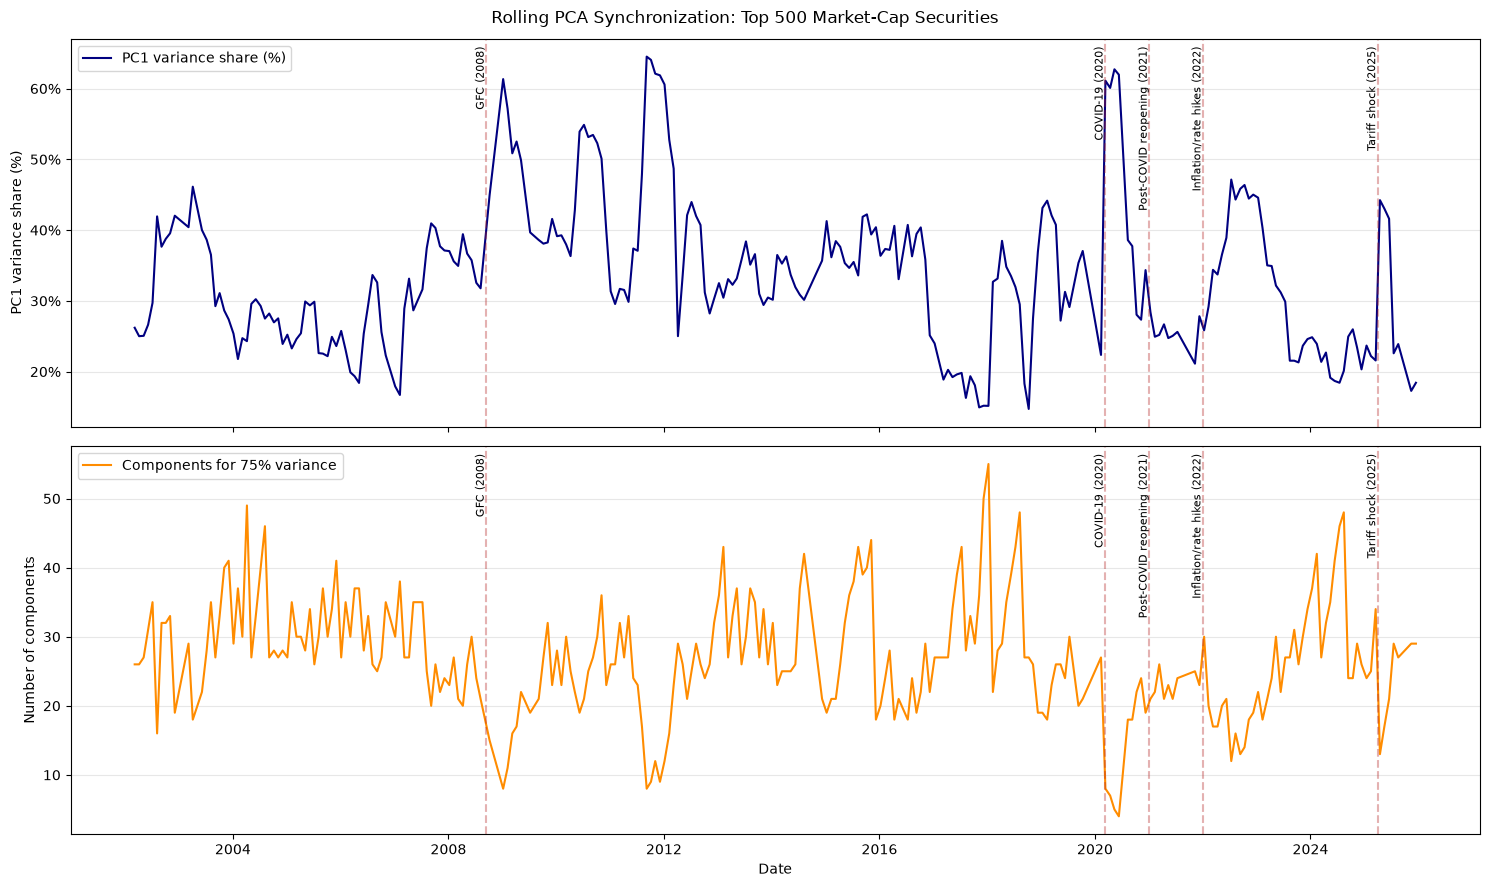

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_sample_size = 500
rolling_pca_rows = []
rolling_pca_scree_by_date = {}

def get_complete_top_cap_window(evaluation_date, universe_size):
    window_returns = correlation_returns.loc[:evaluation_date].tail(rolling_window_days)
    valid_securities = window_returns.count().loc[lambda counts: counts >= minimum_observations].index
    selected_securities = market_cap_returns.loc[evaluation_date, valid_securities].nlargest(universe_size).index
    return window_returns[selected_securities].dropna(how="any")

for evaluation_date in evaluation_dates:
    complete_window_returns = get_complete_top_cap_window(evaluation_date, pca_sample_size)

    if len(complete_window_returns) < minimum_observations or complete_window_returns.shape[1] < 2:
        continue

    standardized_window_returns = StandardScaler(with_mean=True, with_std=True).fit_transform(complete_window_returns)
    rolling_pca = PCA().fit(standardized_window_returns)
    explained_variance_ratios = rolling_pca.explained_variance_ratio_
    cumulative_explained_variance = np.cumsum(explained_variance_ratios)
    first_component_scores = rolling_pca.transform(standardized_window_returns)[:, 0]
    cap_weighted_window_returns = cap_weighted_returns.reindex(complete_window_returns.index)
    pc1_index_correlation = pd.Series(first_component_scores, index=complete_window_returns.index).corr(cap_weighted_window_returns)

    first_eigenvector = rolling_pca.components_[0]
    rolling_pca_rows.append({
        "date": evaluation_date,
        "first_component_variance_share": explained_variance_ratios[0],
        "components_for_75pct_variance": int(np.searchsorted(cumulative_explained_variance, 0.75) + 1),
        "pc1_effective_number_of_stocks": 1.0 / np.sum(first_eigenvector**4),
        "pc1_cap_weighted_index_correlation": pc1_index_correlation,
        "securities_used": complete_window_returns.shape[1],
        "observations_used": complete_window_returns.shape[0],
    })
    rolling_pca_scree_by_date[evaluation_date] = explained_variance_ratios

rolling_pca_summary = pd.DataFrame(rolling_pca_rows).set_index("date")
rolling_pca_loading_concentration = rolling_pca_summary[["pc1_effective_number_of_stocks"]]
rolling_pc1_index_correlation = rolling_pca_summary[["pc1_cap_weighted_index_correlation"]]

print(f"Rolling PCA windows: {len(rolling_pca_summary):,}")
print(f"PCA universe size: top {pca_sample_size:,} market-cap securities")
print(f"Standardized observations and securities in final window: {rolling_pca_summary.iloc[-1]['observations_used']:,.0f} and {rolling_pca_summary.iloc[-1]['securities_used']:,.0f}")
print(f"PC1 variance-share range: {rolling_pca_summary['first_component_variance_share'].min():.1%} to {rolling_pca_summary['first_component_variance_share'].max():.1%}")
print(f"Components-for-75%-variance range: {rolling_pca_summary['components_for_75pct_variance'].min()} to {rolling_pca_summary['components_for_75pct_variance'].max()}")
rolling_pca_summary_display = rolling_pca_summary.head(3).rename(
    columns={
        "first_component_variance_share": "first_component_variance_share (%)",
        "components_for_75pct_variance": "components_for_75pct_variance (count)",
        "securities_used": "securities_used (count)",
        "observations_used": "observations_used (count)",
    }
).copy()
rolling_pca_summary_display["first_component_variance_share (%)"] *= 100

figure, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(
    rolling_pca_summary.index,
    rolling_pca_summary["first_component_variance_share"],
    color="navy",
    label="PC1 variance share (%)",
)
axes[0].set_ylabel("PC1 variance share (%)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()
axes[1].plot(
    rolling_pca_summary.index,
    rolling_pca_summary["components_for_75pct_variance"],
    color="darkorange",
    label="Components for 75% variance",
)
axes[1].set_ylabel("Number of components")
axes[1].set_xlabel("Date")
axes[1].legend()
for axis in axes:
    add_stress_markers(axis)
    axis.grid(axis="y", alpha=0.3)
figure.suptitle(f"Rolling PCA Synchronization: Top {pca_sample_size} Market-Cap Securities")
figure.tight_layout()
plt.show()

## Summarising Rolling PCA - market-wide synchronization ##
- The first component variance (PC1) share is a measure of how much of the total variance in the data is explained by the first principal component. A higher value indicates that a single factor (the first principal component) is driving the returns of the stocks in the market. This is often interpreted as a measure of market-wide synchronization, where a higher value suggests that the market is more synchronized and that individual stock returns are more influenced by common factors rather than idiosyncratic factors.
- As we would expect, the PC1 variance share spikes during market stress scenarios. Also, during these scenarios, since the PC1 variance share goes up, the number of componennts needed to explain 75% of the total variance goes down.
- As noted in the correlation analysis, the 2012-2013 period shows market synchrinisation as well. This is consistent with the correlation analysis and further supports the idea that this period was driven by macro factors rather than idiosyncratic shocks.

### 6a. PC1 loading concentration

The effective number of stocks is the inverse Herfindahl index of the unit-norm PC1 eigenvector loadings. It estimates how many stocks effectively drive PC1: values near 500 indicate broad-based loading, while values near 1 indicate concentration in a small number of stocks.

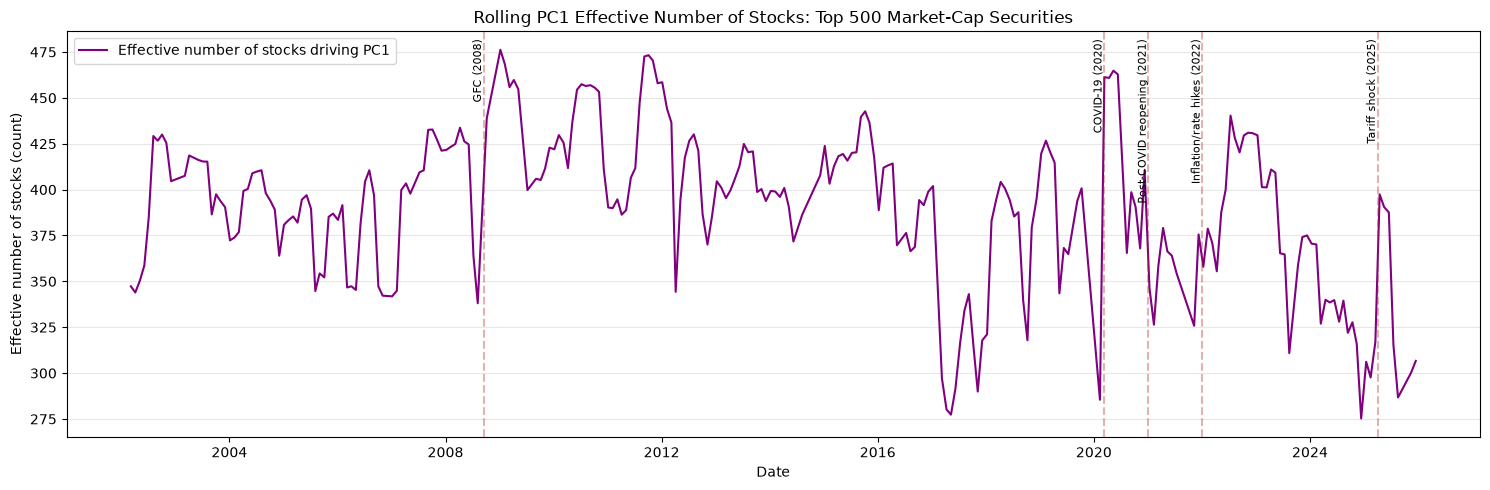

In [8]:
rolling_pca_loading_concentration_display = rolling_pca_loading_concentration.head(3).rename(
    columns={"pc1_effective_number_of_stocks": "pc1_effective_number_of_stocks (count)"}
)

figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(rolling_pca_loading_concentration, color="purple", label="Effective number of stocks driving PC1")
axis.set(
    title=f"Rolling PC1 Effective Number of Stocks: Top {pca_sample_size} Market-Cap Securities",
    xlabel="Date",
    ylabel="Effective number of stocks (count)",
)
axis.legend()
axis.grid(axis="y", alpha=0.3)
add_stress_markers(axis)
figure.tight_layout()
plt.show()

`Effective number of stocks driving PC1`
- This metric is interesting and shows market concentration. We typically hear that the entire market is driven by tech stocks or the AI hype but that has an implicit assumption of market cap. Ofcourse, when the top 10 stocks comprise of a siginificant portion of the market cap, they will drive the market. However, this metric is different and shows how many stocks are effectively driving the market regardless of their size. This is a more interesting measure to study diversification and market concentration.
- Interestingly, the effective number of stocks driving PC1 is not as concentrated during the GFC and covid periods. This is because these are idiosyncratic shocks that affect a large number of stocks. However, the 2012-2013 period shows a high concentration of stocks driving PC1. This is consistent with the correlation analysis and further supports the idea that this period was driven by macro factors rather than idiosyncratic shocks.
- This chart reveals something quite interesting. The period of 2017-2018 has a lower number of stocks driving PC1 which is consistent with the correlation analysis. It could be interesting to study what causes this behavior.

### 6b. Scree plot at representative dates

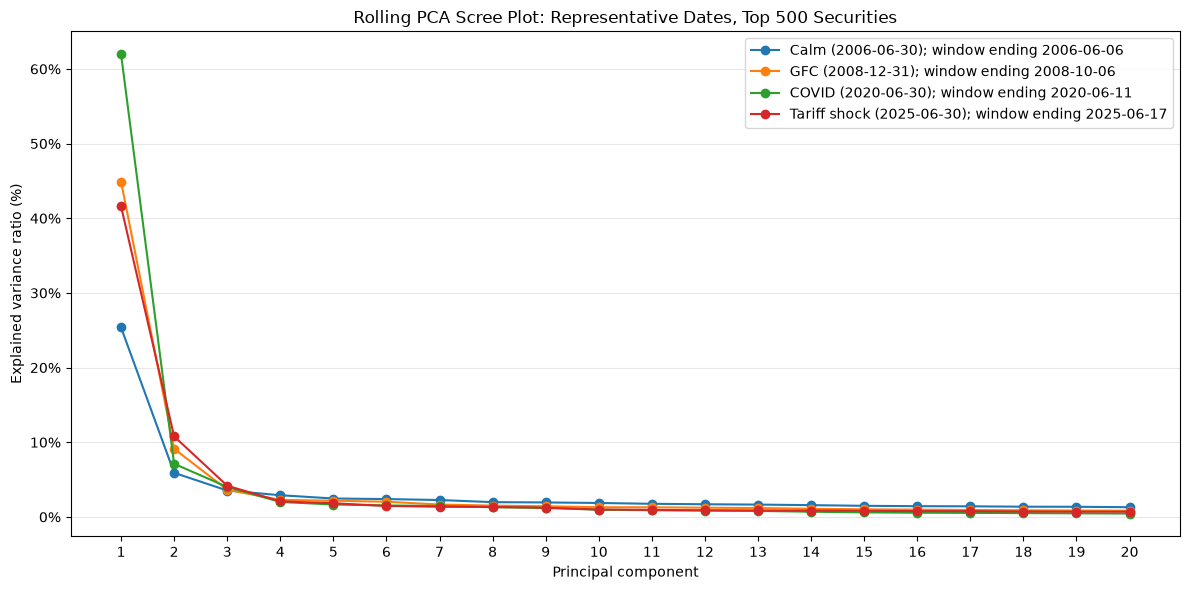

In [9]:
representative_pca_dates = {
    "Calm (2006-06-30)": pd.Timestamp("2006-06-30"),
    "GFC (2008-12-31)": pd.Timestamp("2008-12-31"),
    "COVID (2020-06-30)": pd.Timestamp("2020-06-30"),
    "Tariff shock (2025-06-30)": pd.Timestamp("2025-06-30"),
}

figure, axis = plt.subplots(figsize=(12, 6))
for label, requested_date in representative_pca_dates.items():
    available_dates = [date for date in rolling_pca_scree_by_date if date <= requested_date]
    if not available_dates:
        print(f"No rolling PCA window available on or before {requested_date.date()} for {label}.")
        continue
    selected_date = max(available_dates)
    explained_variance_ratios = rolling_pca_scree_by_date[selected_date]
    component_count = min(20, len(explained_variance_ratios))
    axis.plot(
        np.arange(1, component_count + 1),
        explained_variance_ratios[:component_count],
        marker="o",
        linewidth=1.5,
        label=f"{label}; window ending {selected_date.date()}",
    )

axis.set(
    title=f"Rolling PCA Scree Plot: Representative Dates, Top {pca_sample_size} Securities",
    xlabel="Principal component",
    ylabel="Explained variance ratio (%)",
)
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_xticks(np.arange(1, 21))
axis.grid(axis="y", alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()